<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/dtqem_mass_effect_demo_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Δτ_MZ = 2.500e-07 s
V_env = 0.023518
γ_ref = 1.000013


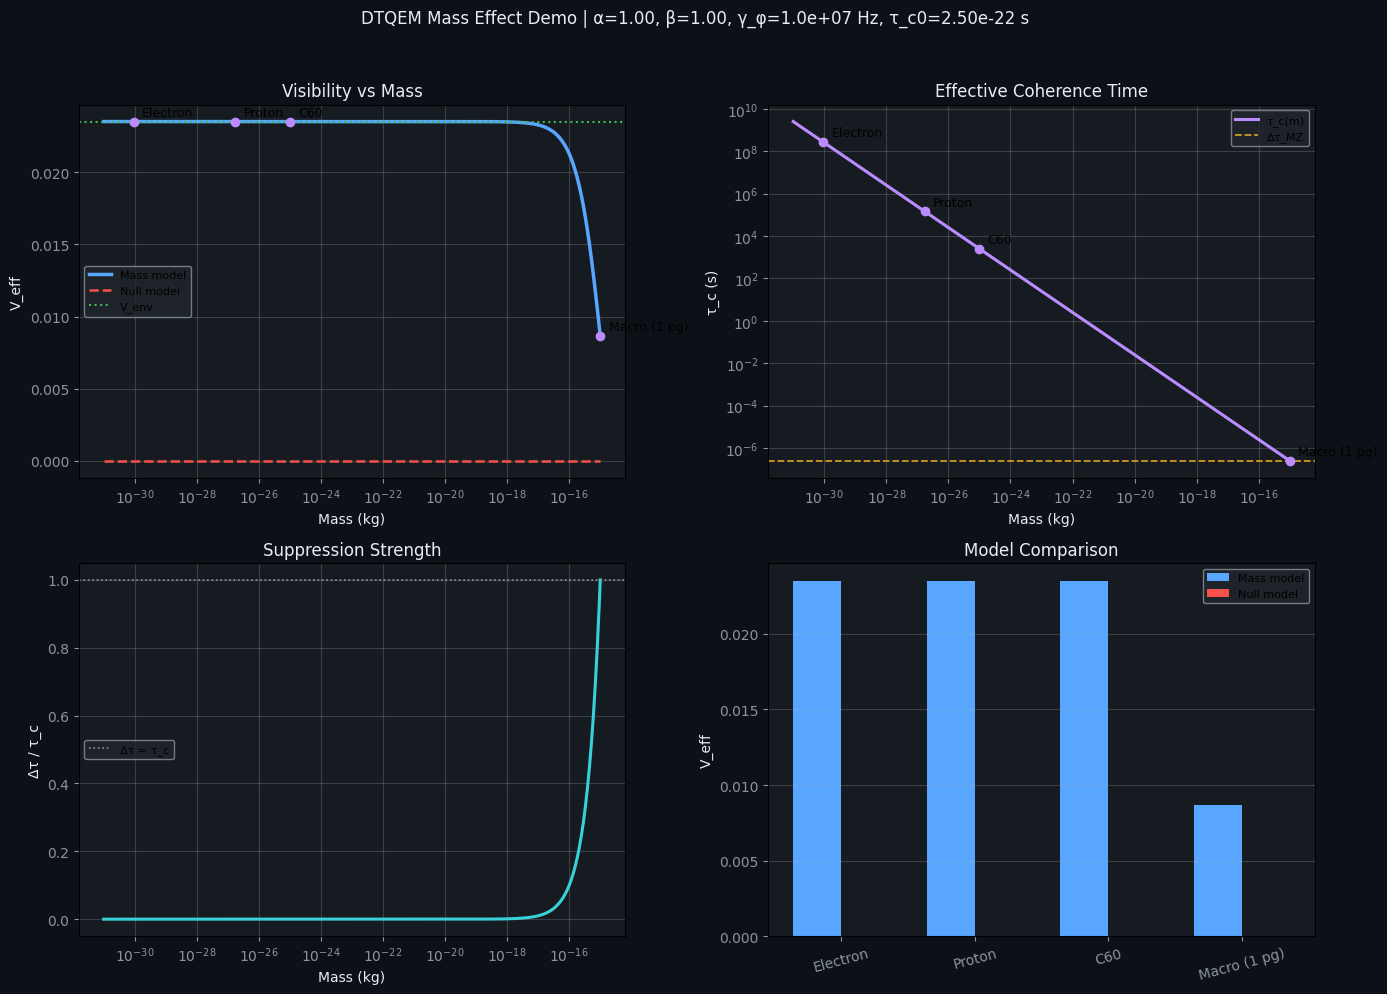

DTQEM Mass Effect Demo — v3.1 (Experimental, Bugfix)
α (velocity exponent) = 1.0
β (mass exponent) = 1.0
γ_ref = 1.000013
V_env = 0.023518
Δτ_MZ = 2.500e-07 s
τ_c0 = 2.500e-22 s
PNG saved to: output/dtqem_mass_effect_demo_v3.png
CSV saved to: output/dtqem_mass_effect_demo_v3.csv
Selected particles:
------------------------------------------------------------------------
Particle        Mass (kg)    τ_c (s)      V_dtqem    V_eff     
------------------------------------------------------------------------
Electron        9.109e-31   2.744e+08   1.000000   0.023518
Proton          1.673e-27   1.495e+05   1.000000   0.023518
C60             9.963e-26   2.509e+03   1.000000   0.023518
Macro (1 pg)    1.000e-15   2.500e-07   0.367871   0.008651


In [4]:

"""
dtqem_mass_effect_demo_v3.py
=============================
Experimental Demo: Mass-Dependent DTQEM Decoherence — V3 (Final)

EXPERIMENTAL — NOT PART OF BASELINE D0

This module explores a hypothetical extension of DTQEM where the characteristic
coherence time τ_c depends on the particle mass and Lorentz factor:

    τ_c(m, γ) = τ_c0 * (m_ref / m)**β / (γ**α)

The model is applied to a Mach-Zehnder interferometer with fixed geometry
(L1 = L2 = 0.5 m, v1 = 1e6 m/s, v2 = 2e6 m/s). The user can vary α and β
to test how visibility V_eff changes with particle mass.

Purpose:
    - Illustrate the logic behind prediction P9 (heavier particles lose
      coherence faster if τ_c decreases with mass).
    - Provide a visual and quantitative tool for discussing mass-dependent
      decoherence in DTQEM.
    - Generate CSV output for further analysis.

Key Parameters:
    - α (alpha): exponent for Lorentz factor γ (velocity dependence)
    - β (beta):  exponent for mass (mass dependence)
    - τ_c0:      base coherence time at m = m_ref and γ = 1

Outputs:
    - Four-panel figure saved as PNG.
    - CSV file with selected particle results.

Author : DTQEM Team — Berramdane Reddouane
AI Contribution: Claude (Anthropic) — coding, optimization, and documentation
Version: 3.1 (bugfix)
Date: 2026-05-24
License: MIT
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import csv

# ============================================================================
# Physical Constants
# ============================================================================
C_LIGHT = 299_792_458.0          # speed of light [m/s]
LORENTZ_SAFETY = 0.9999          # safety threshold for v/c


# ============================================================================
# Core Physics Functions (Mach-Zehnder, same as v46.0)
# ============================================================================

def lorentz_gamma(v: float) -> float:
    """Lorentz factor γ = 1 / √(1 - (v/c)²)."""
    beta = np.clip(abs(v) / C_LIGHT, 0.0, LORENTZ_SAFETY)
    return 1.0 / np.sqrt(1.0 - beta**2)


def tau_lab(L: float, v: float) -> float:
    """Lab-frame transit time: τ = L / v [s]."""
    return L / v if v > 0 else np.inf


def tau_proper(L: float, v: float) -> float:
    """Proper time along one arm: τ* = τ / γ = L / (v·γ) [s]."""
    return tau_lab(L, v) / lorentz_gamma(v)


def delta_tau_MZ(L1: float, v1: float, L2: float, v2: float) -> float:
    """Proper-time mismatch between arms: Δτ_MZ = |τ₁* − τ₂*|."""
    return abs(tau_proper(L1, v1) - tau_proper(L2, v2))


def T_eff_fn(L1: float, v1: float, L2: float, v2: float) -> float:
    """Effective environmental interaction time: T_eff = (τ₁ + τ₂)/2 [s]."""
    return 0.5 * (tau_lab(L1, v1) + tau_lab(L2, v2))


def V_env(T_eff: float, gamma_phi: float) -> float:
    """Environmental decoherence: V_env = exp(-γ_φ · T_eff)."""
    return np.exp(-gamma_phi * T_eff)


def V_dtqem(delta_tau: float, tau_c: np.ndarray) -> np.ndarray:
    """
    DTQEM decoherence: V_dtqem = exp(-|Δτ| / τ_c).
    Works with both scalar and array inputs.
    """
    return np.exp(-delta_tau / np.maximum(tau_c, 1e-300))


def V_eff_MZ(L1: float, v1: float, L2: float, v2: float,
             gamma_phi: float, tau_c: float) -> float:
    """Total coherence: V_eff = V_env × V_dtqem (scalar version)."""
    T_eff = T_eff_fn(L1, v1, L2, v2)
    dt = delta_tau_MZ(L1, v1, L2, v2)
    return V_env(T_eff, gamma_phi) * V_dtqem(dt, tau_c)


# ============================================================================
# Mass-Dependent τ_c Model (Experimental)
# ============================================================================

def tau_c_mass_dependent(mass: np.ndarray, tau_c0: float,
                         gamma_ref: float,
                         alpha: float = 1.0,
                         beta: float = 1.0,
                         m_ref: float = 1.0) -> np.ndarray:
    """
    Mass-dependent coherence time (experimental).

    Formula:
        τ_c(m) = τ_c0 * (m_ref / m)**β / (γ_ref**α)

    Args:
        mass: Particle mass [kg] (can be array).
        tau_c0: Base coherence time at m = m_ref, γ = 1.
        gamma_ref: Lorentz factor at reference velocity.
        alpha: Exponent for γ (velocity sensitivity).
        beta:  Exponent for mass (mass sensitivity).
        m_ref: Reference mass [kg] (default 1 kg).

    Returns:
        Effective τ_c [s] (same shape as mass).
    """
    mass = np.asarray(mass, dtype=float)
    return tau_c0 * (m_ref / mass) ** beta / (gamma_ref ** alpha)


# ============================================================================
# Main Demo
# ============================================================================

def main():
    # Output directory
    out_dir = Path("output")
    out_dir.mkdir(exist_ok=True)

    # ========================================================================
    # Fixed Mach-Zehnder Parameters
    # ========================================================================
    L1, L2 = 0.5, 0.5           # arm lengths [m]
    v1, v2 = 1e6, 2e6           # particle velocities [m/s]
    gamma_phi = 1e7             # environmental decoherence rate [Hz]
    tau_c0 = 2.5e-22            # base coherence time [s]
    alpha = 1.0                 # exponent for γ (velocity)
    beta = 1.0                  # exponent for mass
    m_ref = 1.0                 # reference mass [kg]

    # Reference velocity and Lorentz factor
    v_ref = 0.5 * (v1 + v2)
    gamma_ref = lorentz_gamma(v_ref)

    # Base Mach-Zehnder quantities (mass-independent)
    delta_tau_val = delta_tau_MZ(L1, v1, L2, v2)
    T_eff_val = T_eff_fn(L1, v1, L2, v2)
    V_env_val = V_env(T_eff_val, gamma_phi)

    print(f"Δτ_MZ = {delta_tau_val:.3e} s")
    print(f"V_env = {V_env_val:.6f}")
    print(f"γ_ref = {gamma_ref:.6f}")

    # ========================================================================
    # Mass Sweep
    # ========================================================================
    masses = np.logspace(-31, -15, 500)          # from electron to macro
    tau_c_mass = tau_c_mass_dependent(masses, tau_c0, gamma_ref,
                                      alpha=alpha, beta=beta, m_ref=m_ref)
    V_dtqem_mass = V_dtqem(delta_tau_val, tau_c_mass)
    V_eff_mass = V_env_val * V_dtqem_mass

    # Null model (τ_c constant, mass-independent)
    tau_c_null = tau_c0 * np.ones_like(masses)
    V_dtqem_null = V_dtqem(delta_tau_val, tau_c_null)
    V_eff_null = V_env_val * V_dtqem_null

    # ========================================================================
    # Selected Particles for Summary Table
    # ========================================================================
    particle_data = [
        ("Electron", 9.109383701e-31),
        ("Proton", 1.67262192369e-27),
        ("C60", 60 * 1.66053906660e-27),
        ("Macro (1 pg)", 1e-15),
    ]

    rows = []
    for name, m in particle_data:
        tc = tau_c_mass_dependent(np.array([m]), tau_c0, gamma_ref,
                                  alpha=alpha, beta=beta, m_ref=m_ref)[0]
        vdt = V_dtqem(delta_tau_val, np.array([tc]))[0]
        vef = V_env_val * vdt
        rows.append([name, m, tc, vdt, vef, np.log10(tc)])

    # ========================================================================
    # Four-Panel Figure
    # ========================================================================
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.patch.set_facecolor('#0d1117')
    ax1, ax2, ax3, ax4 = axs.flatten()

    # Panel 1: V_eff vs mass
    ax1.semilogx(masses, V_eff_mass, color='#58a6ff', lw=2.5, label='Mass model')
    ax1.semilogx(masses, V_eff_null, color='#f85149', lw=1.8, ls='--', label='Null model')
    ax1.axhline(V_env_val, color='#3fb950', lw=1.5, ls=':', label='V_env')
    for name, m in particle_data:
        idx = np.argmin(np.abs(masses - m))
        ax1.plot(masses[idx], V_eff_mass[idx], 'o', ms=6, color='#bc8cff')
        ax1.annotate(name, (masses[idx], V_eff_mass[idx]), xytext=(6, 4),
                     textcoords='offset points', fontsize=9)
    ax1.set_xlabel('Mass (kg)', color='#e6edf3')
    ax1.set_ylabel('V_eff', color='#e6edf3')
    ax1.set_title('Visibility vs Mass', color='#e6edf3')
    ax1.grid(True, alpha=0.25)
    ax1.legend(fontsize=8, facecolor='#21262d', edgecolor='#8b949e')
    ax1.set_facecolor('#161b22')
    ax1.tick_params(colors='#8b949e')

    # Panel 2: τ_c(m)
    ax2.loglog(masses, tau_c_mass, color='#bc8cff', lw=2.2, label='τ_c(m)')
    ax2.axhline(delta_tau_val, color='#d29922', ls='--', lw=1.3, label='Δτ_MZ')
    for name, m in particle_data:
        idx = np.argmin(np.abs(masses - m))
        ax2.plot(masses[idx], tau_c_mass[idx], 'o', ms=6, color='#bc8cff')
        ax2.annotate(name, (masses[idx], tau_c_mass[idx]), xytext=(6, 4),
                     textcoords='offset points', fontsize=9)
    ax2.set_xlabel('Mass (kg)', color='#e6edf3')
    ax2.set_ylabel('τ_c (s)', color='#e6edf3')
    ax2.set_title('Effective Coherence Time', color='#e6edf3')
    ax2.grid(True, which='both', alpha=0.25)
    ax2.legend(fontsize=8, facecolor='#21262d', edgecolor='#8b949e')
    ax2.set_facecolor('#161b22')
    ax2.tick_params(colors='#8b949e')

    # Panel 3: Δτ/τ_c ratio
    ratio = delta_tau_val / np.maximum(tau_c_mass, 1e-300)
    ax3.semilogx(masses, ratio, color='#39d0d8', lw=2.2)
    ax3.axhline(1.0, color='#8b949e', ls=':', lw=1.2, label='Δτ = τ_c')
    ax3.set_xlabel('Mass (kg)', color='#e6edf3')
    ax3.set_ylabel('Δτ / τ_c', color='#e6edf3')
    ax3.set_title('Suppression Strength', color='#e6edf3')
    ax3.grid(True, alpha=0.25)
    ax3.legend(fontsize=8, facecolor='#21262d', edgecolor='#8b949e')
    ax3.set_facecolor('#161b22')
    ax3.tick_params(colors='#8b949e')

    # Panel 4: Bar chart for selected particles
    labels = [r[0] for r in rows]
    veff_mass_pts = [r[4] for r in rows]
    veff_null_pts = [V_env_val * V_dtqem(delta_tau_val, np.array([tau_c0]))[0]] * len(rows)
    x = np.arange(len(labels))
    width = 0.36
    ax4.bar(x - width/2, veff_mass_pts, width, color='#58a6ff', label='Mass model')
    ax4.bar(x + width/2, veff_null_pts, width, color='#f85149', label='Null model')
    ax4.set_xticks(x)
    ax4.set_xticklabels(labels, rotation=15, color='#e6edf3')
    ax4.set_ylabel('V_eff', color='#e6edf3')
    ax4.set_title('Model Comparison', color='#e6edf3')
    ax4.grid(True, axis='y', alpha=0.25)
    ax4.legend(fontsize=8, facecolor='#21262d', edgecolor='#8b949e')
    ax4.set_facecolor('#161b22')
    ax4.tick_params(colors='#8b949e')

    fig.suptitle(f'DTQEM Mass Effect Demo | α={alpha:.2f}, β={beta:.2f}, '
                 f'γ_φ={gamma_phi:.1e} Hz, τ_c0={tau_c0:.2e} s',
                 y=0.99, color='#e6edf3', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.965])

    # Save PNG
    out_png = out_dir / 'dtqem_mass_effect_demo_v3.png'
    fig.savefig(out_png, dpi=180, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    plt.close(fig)

    # ========================================================================
    # Export CSV
    # ========================================================================
    out_csv = out_dir / 'dtqem_mass_effect_demo_v3.csv'
    with out_csv.open('w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['particle', 'mass_kg', 'tau_c_s', 'V_dtqem', 'V_eff', 'log10_tau_c'])
        writer.writerows(rows)

    # ========================================================================
    # Console Summary
    # ========================================================================
    print('=' * 72)
    print('DTQEM Mass Effect Demo — v3.1 (Experimental, Bugfix)')
    print('=' * 72)
    print(f'α (velocity exponent) = {alpha}')
    print(f'β (mass exponent) = {beta}')
    print(f'γ_ref = {gamma_ref:.6f}')
    print(f'V_env = {V_env_val:.6f}')
    print(f'Δτ_MZ = {delta_tau_val:.3e} s')
    print(f'τ_c0 = {tau_c0:.3e} s')
    print(f'PNG saved to: {out_png}')
    print(f'CSV saved to: {out_csv}')
    print('=' * 72)
    print('Selected particles:')
    print('-' * 72)
    print(f"{'Particle':<15} {'Mass (kg)':<12} {'τ_c (s)':<12} {'V_dtqem':<10} {'V_eff':<10}")
    print('-' * 72)
    for name, m, tc, vdt, vef, _ in rows:
        print(f'{name:<15} {m:.3e}   {tc:.3e}   {vdt:.6f}   {vef:.6f}')
    print('=' * 72)


if __name__ == "__main__":
    main()